<a href="https://colab.research.google.com/github/soup511/ML/blob/main/UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
x,y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)


In [5]:
df=pd.DataFrame(x,columns=['feature1','feature2'])
df.head()

,feature1,feature2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542


In [6]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [7]:
inertia=[]
k_range=range(1,11)

In [8]:
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [9]:
inertia

[600.0000000000001,
 270.3431137506444,
 191.27421726522272,
 56.024770575099495,
 49.448585387935665,
 42.64361661581214,
 36.898261535193974,
 29.491821088221275,
 28.164080730057197,
 26.37569060444803]

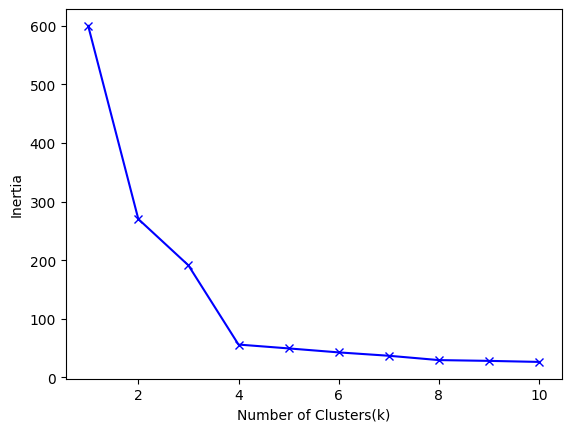

In [10]:
plt.plot(k_range,inertia,'bx-')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.show()

In [11]:
from sklearn import cluster
kmeans_final=KMeans(n_clusters=4,random_state=42)
cluster_labels=kmeans_final.fit_predict(x_scaled)

In [12]:
cluster_labels

array([0, 1, 2, 1, 0, 0, 3, 2, 1, 1, 3, 1, 2, 1, 0, 2, 2, 0, 3, 3, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 0, 2, 3, 2, 2,
       3, 3, 1, 3, 1, 0, 3, 0, 1, 0, 0, 3, 1, 3, 1, 0, 1, 2, 1, 3, 3, 3,
       1, 0, 1, 3, 2, 3, 1, 3, 3, 1, 3, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2,
       1, 1, 2, 0, 1, 3, 3, 2, 0, 0, 2, 3, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2,
       3, 3, 0, 1, 0, 2, 1, 0, 0, 2, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 1, 3,
       3, 0, 1, 3, 3, 1, 2, 1, 1, 3, 2, 3, 2, 3, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 3, 1, 3, 0, 2, 1, 2, 2, 0, 2, 3, 3, 2, 0, 2, 2, 1, 0, 2, 3, 1,
       0, 0, 2, 3, 0, 2, 3, 3, 2, 2, 2, 2, 0, 1, 2, 3, 2, 2, 3, 3, 3, 2,
       3, 1, 2, 3, 0, 3, 2, 1, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 0, 0, 3, 0, 3, 2, 1, 1, 2, 2, 1, 2, 0, 3, 2, 0, 3, 1, 3, 0, 2,
       0, 1, 1, 1, 1, 3, 3, 1, 2, 3, 0, 2, 3, 3, 3, 0, 0, 1, 2, 2, 3, 0,
       1, 3, 2, 1, 2, 0, 0, 3, 3, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0,
       1, 3, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 3], d

In [13]:
df['claster']=cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

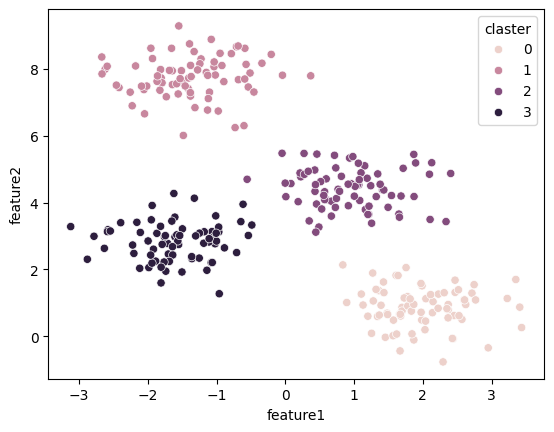

In [14]:
sns.scatterplot(x='feature1',y='feature2',hue='claster',data=df)

In [15]:
from sklearn.datasets import make_moons

In [16]:
x,y_true=make_moons(n_samples=200,noise=0.05,random_state=42)

In [17]:
from sklearn.cluster import KMeans,DBSCAN

In [18]:
df=pd.DataFrame(x,columns=['feature1','feature2'])
df.head()

,feature1,feature2
0,-1.020690,0.105518
1,0.905826,0.457858
2,0.618422,0.757086
3,1.227707,-0.425185
4,0.329356,-0.206946


In [19]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [20]:
kmeans=KMeans(n_clusters=2,random_state=42)
kmeans_labels=kmeans.fit(x_scaled)

In [22]:
df['kmeans_cluster']=kmeans.labels_

<Axes: xlabel='feature1', ylabel='feature2'>

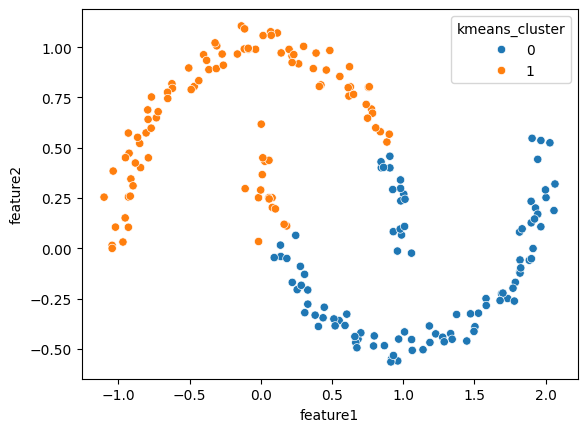

In [24]:
sns.scatterplot(x='feature1',y='feature2',hue='kmeans_cluster',data=df,palette='tab10')

In [25]:
dbscan=DBSCAN(eps=0.2,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled)

In [27]:
df['cluster']=dbscan_labels

<Axes: xlabel='feature1', ylabel='feature2'>

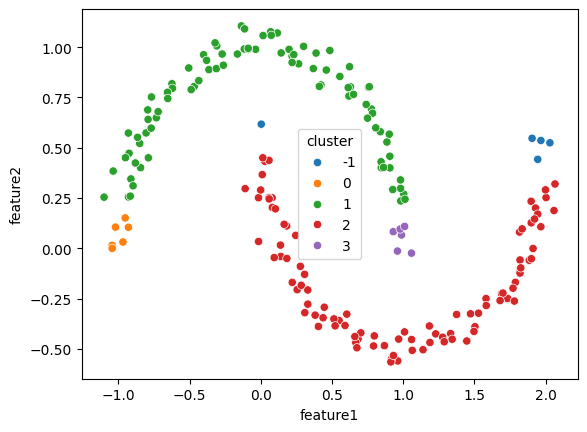

In [28]:
sns.scatterplot(x='feature1',y='feature2',hue='cluster',data=df,palette='tab10')

In [29]:
x,y=make_blobs(n_samples=500,centers=3,cluster_std=1.5,random_state=42)

In [30]:
x

array([[ -5.1557172 ,  -7.93487423],
       [  0.59454887,   1.89172738],
       [  7.92458324,   0.76072226],
       [ -3.09735985,   6.81901371],
       [  6.44169972,   1.36105662],
       [  5.88538256,   0.68904395],
       [ -3.03950038,  -7.02419944],
       [  5.04556407,   1.89781252],
       [  3.03844819,   1.75960046],
       [ -7.81685506,  -6.84097302],
       [  3.67001951,   0.35084768],
       [ -0.77130425,   7.78326265],
       [  0.69035244,   6.08615443],
       [ -1.65286186,  10.71763459],
       [  5.07454112,   5.08627088],
       [  6.22751557,  -0.66493955],
       [ -2.61721281,  10.51958548],
       [ -8.56371022,  -6.30649497],
       [ -6.75620121,  -5.28188903],
       [ -4.16870008,   7.21997619],
       [  2.54202748,   2.81762354],
       [ -2.19590223,   6.07478094],
       [  5.50471428,   2.44004492],
       [ -4.53134115,  -6.97873498],
       [ -7.54927761,  -6.5889746 ],
       [  5.23155705,   1.34169296],
       [  4.25741301,   4.22915917],
 

In [31]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [34]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [35]:
df_pca=pd.DataFrame(x_pca,columns=['PC1','PC2'])
df_pca.head()

,PC1,PC2
0,-1.520143,-0.488015
1,0.358715,-0.261226
2,1.290509,-1.435373
3,0.356277,0.797032
4,1.141811,-1.158035


<Axes: xlabel='PC1', ylabel='PC2'>

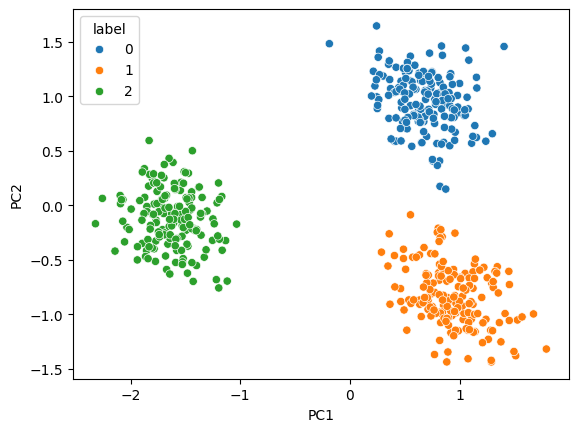

In [37]:
df_pca['label'] = y
sns.scatterplot(data=df_pca,x='PC1',y='PC2',hue='label',palette='tab10')